# UWB Distance Estimation (Regression)

This notebook uses several regression algorithms for distance estimator for two dominant shortest paths

In [15]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# Load Regression Data generated from preprocessing pipeline
data = np.load('multi_regression_data.npz')
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (33600, 104)
y_train shape: (33600, 2)
X_test shape: (8400, 104)
y_test shape: (8400, 2)


## 1. Random Forest Regressor
A strong baseline ensemble learning method.

In [16]:
base_rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf = MultiOutputRegressor(base_rf)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

rf_rmse1 = np.sqrt(mean_squared_error(y_test[:, 0], rf_preds[:, 0]))
rf_mae1 = mean_absolute_error(y_test[:, 0], rf_preds[:, 0])
rf_r21 = r2_score(y_test[:, 0], rf_preds[:, 0])

rf_rmse2 = np.sqrt(mean_squared_error(y_test[:, 1], rf_preds[:, 1]))
rf_mae2 = mean_absolute_error(y_test[:, 1], rf_preds[:, 1])
rf_r22 = r2_score(y_test[:, 1], rf_preds[:, 1])

print("Random Forest Performance:")
print(f"Path 1 - RMSE: {rf_rmse1:.4f} | MAE: {rf_mae1:.4f} | R2: {rf_r21:.4f}")
print(f"Path 2 - RMSE: {rf_rmse2:.4f} | MAE: {rf_mae2:.4f} | R2: {rf_r22:.4f}")

Random Forest Performance:
Path 1 - RMSE: 1.1496 | MAE: 0.8534 | R2: 0.7596
Path 2 - RMSE: 1.3909 | MAE: 1.0165 | R2: 0.7993


## 2. HistGradientBoosting Regressor
A faster, highly performant gradient boosting implementation optimized for large tabular datasets.

In [17]:
base_hgb = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_depth=10, random_state=42)
hgb = MultiOutputRegressor(base_hgb)
hgb.fit(X_train, y_train)

hgb_preds = hgb.predict(X_test)

hgb_rmse1 = np.sqrt(mean_squared_error(y_test[:, 0], hgb_preds[:, 0]))
hgb_mae1 = mean_absolute_error(y_test[:, 0], hgb_preds[:, 0])
hgb_r21 = r2_score(y_test[:, 0], hgb_preds[:, 0])

hgb_rmse2 = np.sqrt(mean_squared_error(y_test[:, 1], hgb_preds[:, 1]))
hgb_mae2 = mean_absolute_error(y_test[:, 1], hgb_preds[:, 1])
hgb_r22 = r2_score(y_test[:, 1], hgb_preds[:, 1])

print("HistGradientBoosting Performance:")
print(f"Path 1 - RMSE: {hgb_rmse1:.4f} | MAE: {hgb_mae1:.4f} | R2: {hgb_r21:.4f}")
print(f"Path 2 - RMSE: {hgb_rmse2:.4f} | MAE: {hgb_mae2:.4f} | R2: {hgb_r22:.4f}")

HistGradientBoosting Performance:
Path 1 - RMSE: 1.1392 | MAE: 0.8577 | R2: 0.7639
Path 2 - RMSE: 1.3526 | MAE: 1.0026 | R2: 0.8102


## 3. Multi-layer Perceptron (MLP) Regressor
A neural network regressor capturing complex, non-linear relationships via hidden layers.

In [18]:
base_mlp = MLPRegressor(hidden_layer_sizes=(128, 64), activation='relu', solver='adam', 
                   early_stopping=True, validation_fraction=0.1, n_iter_no_change=10, 
                   max_iter=500, random_state=42)
mlp = MultiOutputRegressor(base_mlp)
mlp.fit(X_train, y_train)

mlp_preds = mlp.predict(X_test)

mlp_rmse1 = np.sqrt(mean_squared_error(y_test[:, 0], mlp_preds[:, 0]))
mlp_mae1 = mean_absolute_error(y_test[:, 0], mlp_preds[:, 0])
mlp_r21 = r2_score(y_test[:, 0], mlp_preds[:, 0])

mlp_rmse2 = np.sqrt(mean_squared_error(y_test[:, 1], mlp_preds[:, 1]))
mlp_mae2 = mean_absolute_error(y_test[:, 1], mlp_preds[:, 1])
mlp_r22 = r2_score(y_test[:, 1], mlp_preds[:, 1])

print("MLPRegressor Performance:")
print(f"Path 1 - RMSE: {mlp_rmse1:.4f} | MAE: {mlp_mae1:.4f} | R2: {mlp_r21:.4f}")
print(f"Path 2 - RMSE: {mlp_rmse2:.4f} | MAE: {mlp_mae2:.4f} | R2: {mlp_r22:.4f}")

MLPRegressor Performance:
Path 1 - RMSE: 1.1761 | MAE: 0.8931 | R2: 0.7484
Path 2 - RMSE: 1.4346 | MAE: 1.0744 | R2: 0.7865


## Visualization: True vs Predicted Distances

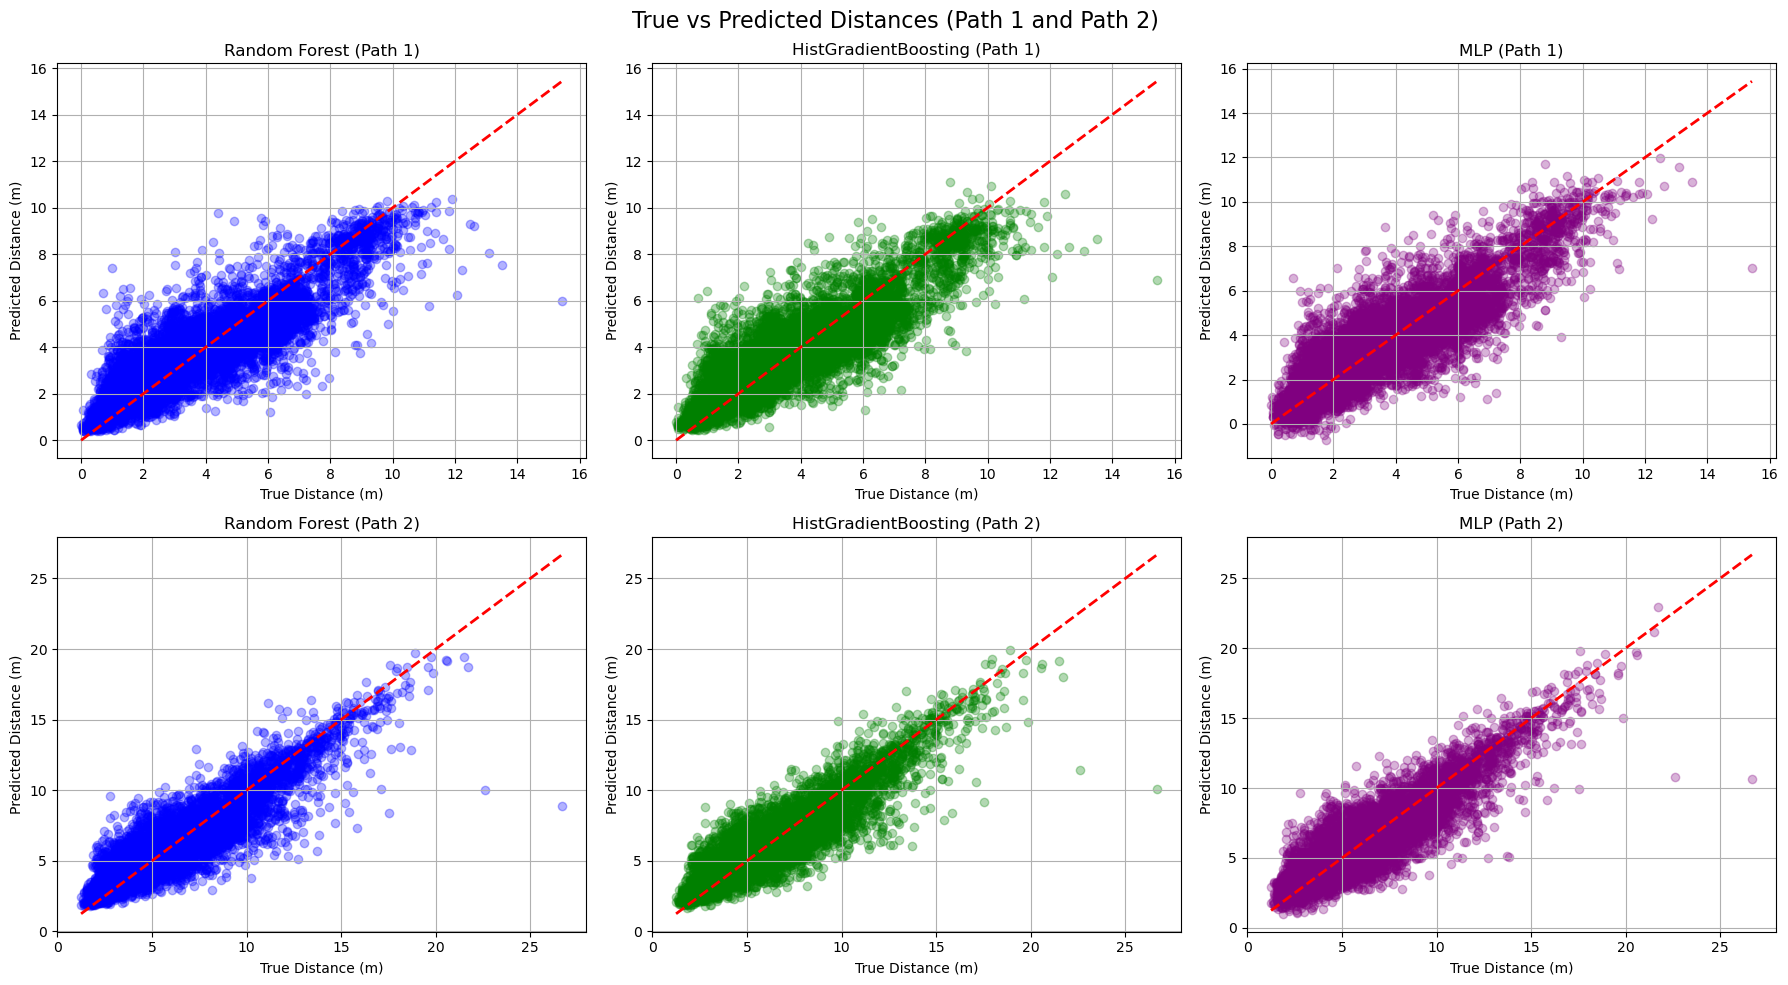

In [19]:
# Setup plots for actual vs predicted for both paths
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("True vs Predicted Distances (Path 1 and Path 2)", fontsize=16)

models = ['Random Forest', 'HistGradientBoosting', 'MLP']
preds = [rf_preds, hgb_preds, mlp_preds]
colors = ['blue', 'green', 'purple']

for i in range(3):
    # Path 1
    axes[0, i].scatter(y_test[:, 0], preds[i][:, 0], alpha=0.3, color=colors[i])
    axes[0, i].plot([y_test[:, 0].min(), y_test[:, 0].max()], [y_test[:, 0].min(), y_test[:, 0].max()], 'r--', lw=2)
    axes[0, i].set_title(f"{models[i]} (Path 1)")
    axes[0, i].set_xlabel("True Distance (m)")
    axes[0, i].set_ylabel("Predicted Distance (m)")
    axes[0, i].grid(True)
    
    # Path 2
    axes[1, i].scatter(y_test[:, 1], preds[i][:, 1], alpha=0.3, color=colors[i])
    axes[1, i].plot([y_test[:, 1].min(), y_test[:, 1].max()], [y_test[:, 1].min(), y_test[:, 1].max()], 'r--', lw=2)
    axes[1, i].set_title(f"{models[i]} (Path 2)")
    axes[1, i].set_xlabel("True Distance (m)")
    axes[1, i].set_ylabel("Predicted Distance (m)")
    axes[1, i].grid(True)

plt.tight_layout()
plt.savefig('regression_actual_vs_predicted_multi.png', dpi=300)
plt.show()

## Visualization: Residual Plots
A residual plot evaluates the variance of the errors. Ideal residual plots have no distinct patterns and are centered tightly around 0.

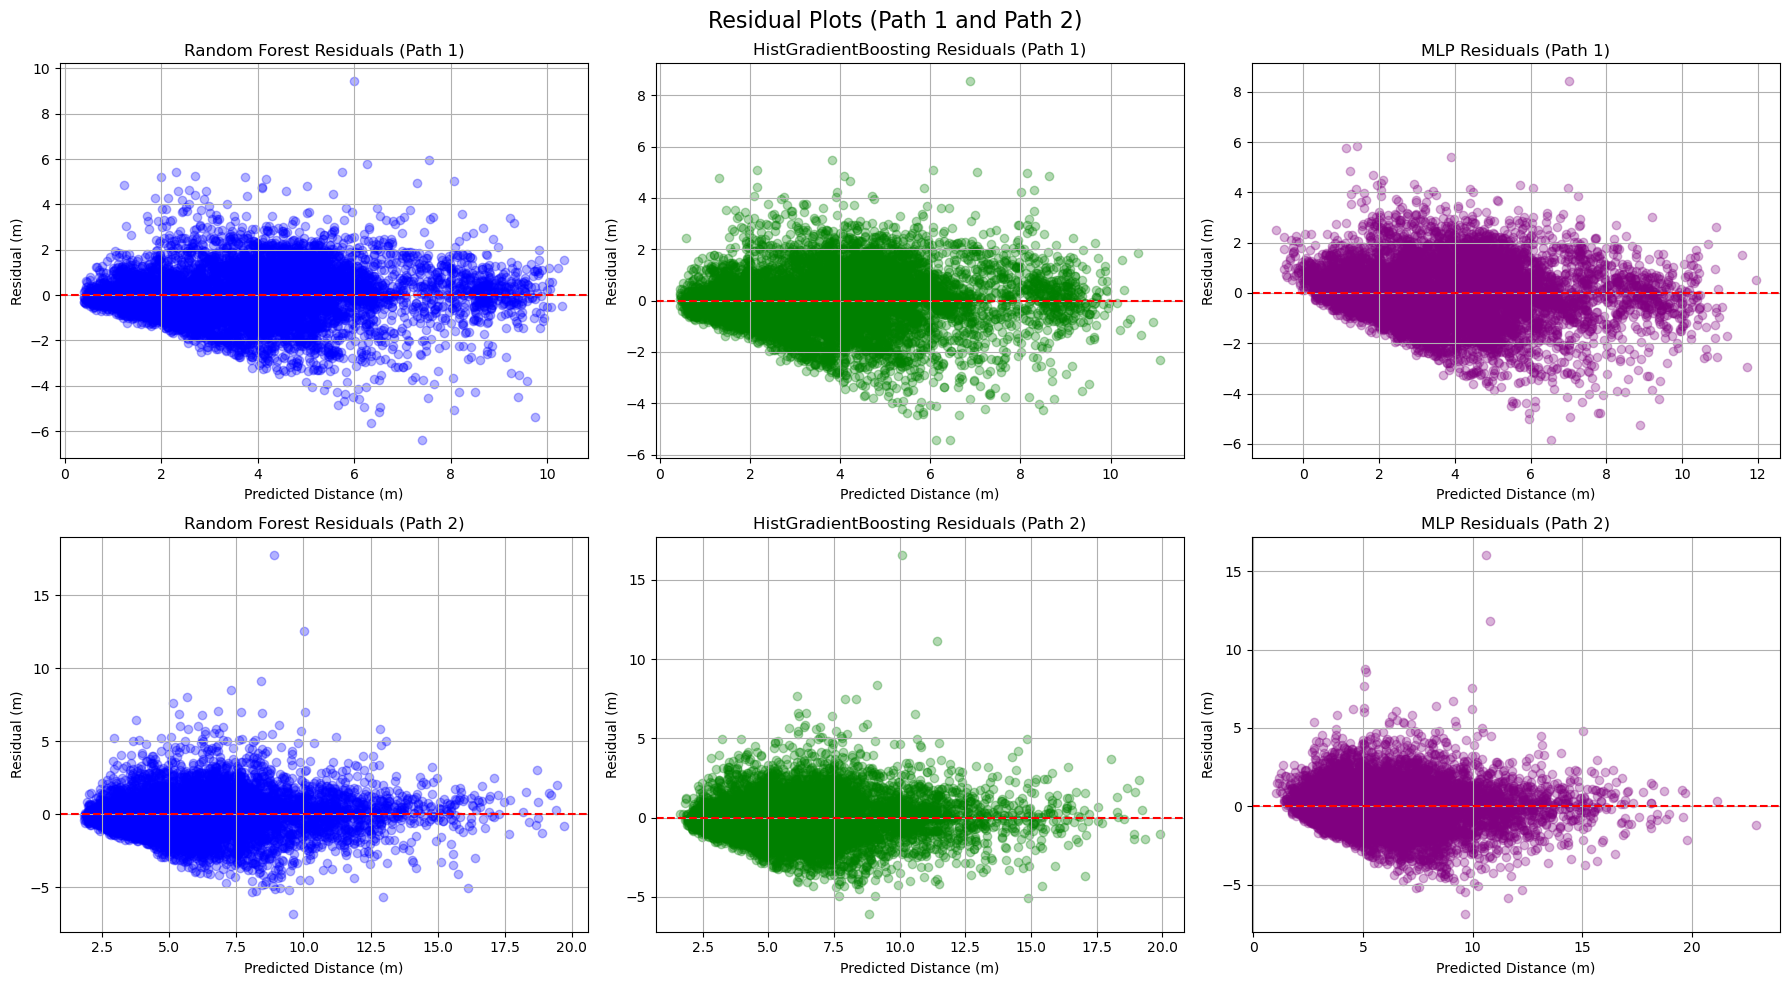

In [20]:
# Compute Residuals for Path 1 and Path 2
rf_res_p1 = y_test[:, 0] - rf_preds[:, 0]
rf_res_p2 = y_test[:, 1] - rf_preds[:, 1]

hgb_res_p1 = y_test[:, 0] - hgb_preds[:, 0]
hgb_res_p2 = y_test[:, 1] - hgb_preds[:, 1]

mlp_res_p1 = y_test[:, 0] - mlp_preds[:, 0]
mlp_res_p2 = y_test[:, 1] - mlp_preds[:, 1]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Residual Plots (Path 1 and Path 2)", fontsize=16)

res_p1 = [rf_res_p1, hgb_res_p1, mlp_res_p1]
res_p2 = [rf_res_p2, hgb_res_p2, mlp_res_p2]

for i in range(3):
    # Path 1
    axes[0, i].scatter(preds[i][:, 0], res_p1[i], alpha=0.3, color=colors[i])
    axes[0, i].axhline(y=0, color='r', linestyle='--')
    axes[0, i].set_title(f"{models[i]} Residuals (Path 1)")
    axes[0, i].set_xlabel("Predicted Distance (m)")
    axes[0, i].set_ylabel("Residual (m)")
    axes[0, i].grid(True)
    
    # Path 2
    axes[1, i].scatter(preds[i][:, 1], res_p2[i], alpha=0.3, color=colors[i])
    axes[1, i].axhline(y=0, color='r', linestyle='--')
    axes[1, i].set_title(f"{models[i]} Residuals (Path 2)")
    axes[1, i].set_xlabel("Predicted Distance (m)")
    axes[1, i].set_ylabel("Residual (m)")
    axes[1, i].grid(True)

plt.tight_layout()
plt.savefig('regression_residuals_multi.png', dpi=300)
plt.show()